In [1]:
import json
import os
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
SOURCE_DIR = "/kaggle/input/datasets/bodduamarnath2004/datasetrp"
OUTPUT_DIR = "/kaggle/working/yolo_ethernet_dataset"
CLASS_MAP = {
    "Ethernet Socket": 0,
    "Power Socket": 1,
    "VGA Socket": 2
}
os.makedirs(f"{OUTPUT_DIR}/images/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/images/val", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels/val", exist_ok=True)
json_files = sorted(glob(os.path.join(SOURCE_DIR, "frame_*.json")))
print(f"Found {len(json_files)} annotated frames")
def json_to_yolo(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    img_width = data.get("imageWidth", 2560)
    img_height = data.get("imageHeight", 1440)
    yolo_lines = []
    for shape in data.get("shapes", []):
        label = shape.get("label")
        if label not in CLASS_MAP:
            continue 
        points = shape.get("points", [])
        if len(points) < 3:
            continue
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        x_center = (x_min + x_max) / 2 / img_width
        y_center = (y_min + y_max) / 2 / img_height
        width    = (x_max - x_min) / img_width
        height   = (y_max - y_min) / img_height
        class_id = CLASS_MAP[label]
        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
    return yolo_lines

image_paths = []
for json_path in json_files:
    frame_id = os.path.basename(json_path).replace(".json", "")
    img_path = os.path.join(SOURCE_DIR, f"{frame_id}.png")
    if not os.path.exists(img_path):
        print(f"Missing image: {img_path}")
        continue
    yolo_lines = json_to_yolo(json_path)
    if yolo_lines: 
        shutil.copy(img_path, f"{OUTPUT_DIR}/images/train/{frame_id}.png")
        label_path = f"{OUTPUT_DIR}/labels/train/{frame_id}.txt"
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))
        image_paths.append(f"{frame_id}.png")

print(f"Successfully converted {len(image_paths)} images with ALL classes")
if len(image_paths) >= 2:
    train_imgs, val_imgs = train_test_split(image_paths, test_size=0.2, random_state=42)
else:
    train_imgs, val_imgs = image_paths, []

for img_name in val_imgs:
    frame_id = img_name.replace(".png", "")
    shutil.move(f"{OUTPUT_DIR}/images/train/{img_name}", f"{OUTPUT_DIR}/images/val/{img_name}")
    shutil.move(f"{OUTPUT_DIR}/labels/train/{frame_id}.txt", f"{OUTPUT_DIR}/labels/val/{frame_id}.txt")

print("Multi-class dataset ready!")
print(f"Train images: {len(train_imgs)} | Val images: {len(val_imgs)}")

Found 16 annotated frames
Successfully converted 16 images with ALL classes
Multi-class dataset ready!
Train images: 12 | Val images: 4


In [2]:
yaml_content = """
path: /kaggle/working/yolo_ethernet_dataset
train: images/train
val: images/val

names:
  0: Ethernet Socket
  1: Power Socket
  2: VGA Socket
"""

with open("/kaggle/working/yolo_ethernet_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created with 3 classes")

data.yaml created with 3 classes


In [3]:
!pip install ultralytics

In [4]:
from ultralytics import YOLO
import os
model = YOLO("yolov9m.pt")
results = model.train(
    data="/kaggle/working/yolo_ethernet_dataset/data.yaml",
    epochs=200,                  
    imgsz=640,
    batch=8,
    patience=40,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    augment=True,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.3,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    flipud=0.5,
    fliplr=0.5,
    freeze=10,
    project="socket_training",
    name="yolov8n_multiclass_run1",
    exist_ok=True,
    verbose=True
)

print("\nTraining finished successfully!")
best_model_path = str(results.save_dir / "weights" / "best.pt")
print("Best model saved at:", best_model_path)
print("\nWeights folder contents:")
!ls -la "{results.save_dir}/weights"

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_ethernet_dataset/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov9m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_multiclass_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ada

In [5]:
from ultralytics import YOLO
import cv2
import os
import glob
model_path = "/kaggle/working/runs/detect/socket_training/yolov8n_multiclass_run1/weights/best.pt"
print("Loading model from:", model_path)

model = YOLO(model_path)
ORIGINAL_IMG_DIR = "/kaggle/input/datasets/bodduamarnath2004/datasetrp"
detections = {}
image_paths = sorted(glob.glob(os.path.join(ORIGINAL_IMG_DIR, "frame_*.png")))
print(f"Found {len(image_paths)} images to process...")
for path in image_paths:
    frame_id = int(os.path.basename(path).split("_")[1].split(".")[0])
    img = cv2.imread(path)
    if img is None:
        continue
    results = model(img)[0]
    boxes = []
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0].cpu().numpy())
        conf = float(box.conf[0].cpu().numpy())
        boxes.append([x1, y1, x2, y2, cls_id, conf])
    detections[frame_id] = boxes
print(f"Detections completed on {len(detections)} frames")
if detections:
    first_key = list(detections.keys())[0]
    print("Example detections (frame", first_key, "):", detections[first_key])

Loading model from: /kaggle/working/runs/detect/socket_training/yolov8n_multiclass_run1/weights/best.pt
Found 16 images to process...

0: 384x640 1 Power Socket, 1 VGA Socket, 75.2ms
Speed: 2.6ms preprocess, 75.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Ethernet Socket, 1 Power Socket, 2 VGA Sockets, 27.3ms
Speed: 2.7ms preprocess, 27.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Ethernet Socket, 1 Power Socket, 1 VGA Socket, 27.4ms
Speed: 2.7ms preprocess, 27.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Ethernet Socket, 1 Power Socket, 1 VGA Socket, 27.3ms
Speed: 2.6ms preprocess, 27.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Ethernet Socket, 1 Power Socket, 1 VGA Socket, 27.3ms
Speed: 2.6ms preprocess, 27.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Ethernet Socket, 1 VGA Socket, 27.2ms
Speed: 

Creating visualizations...


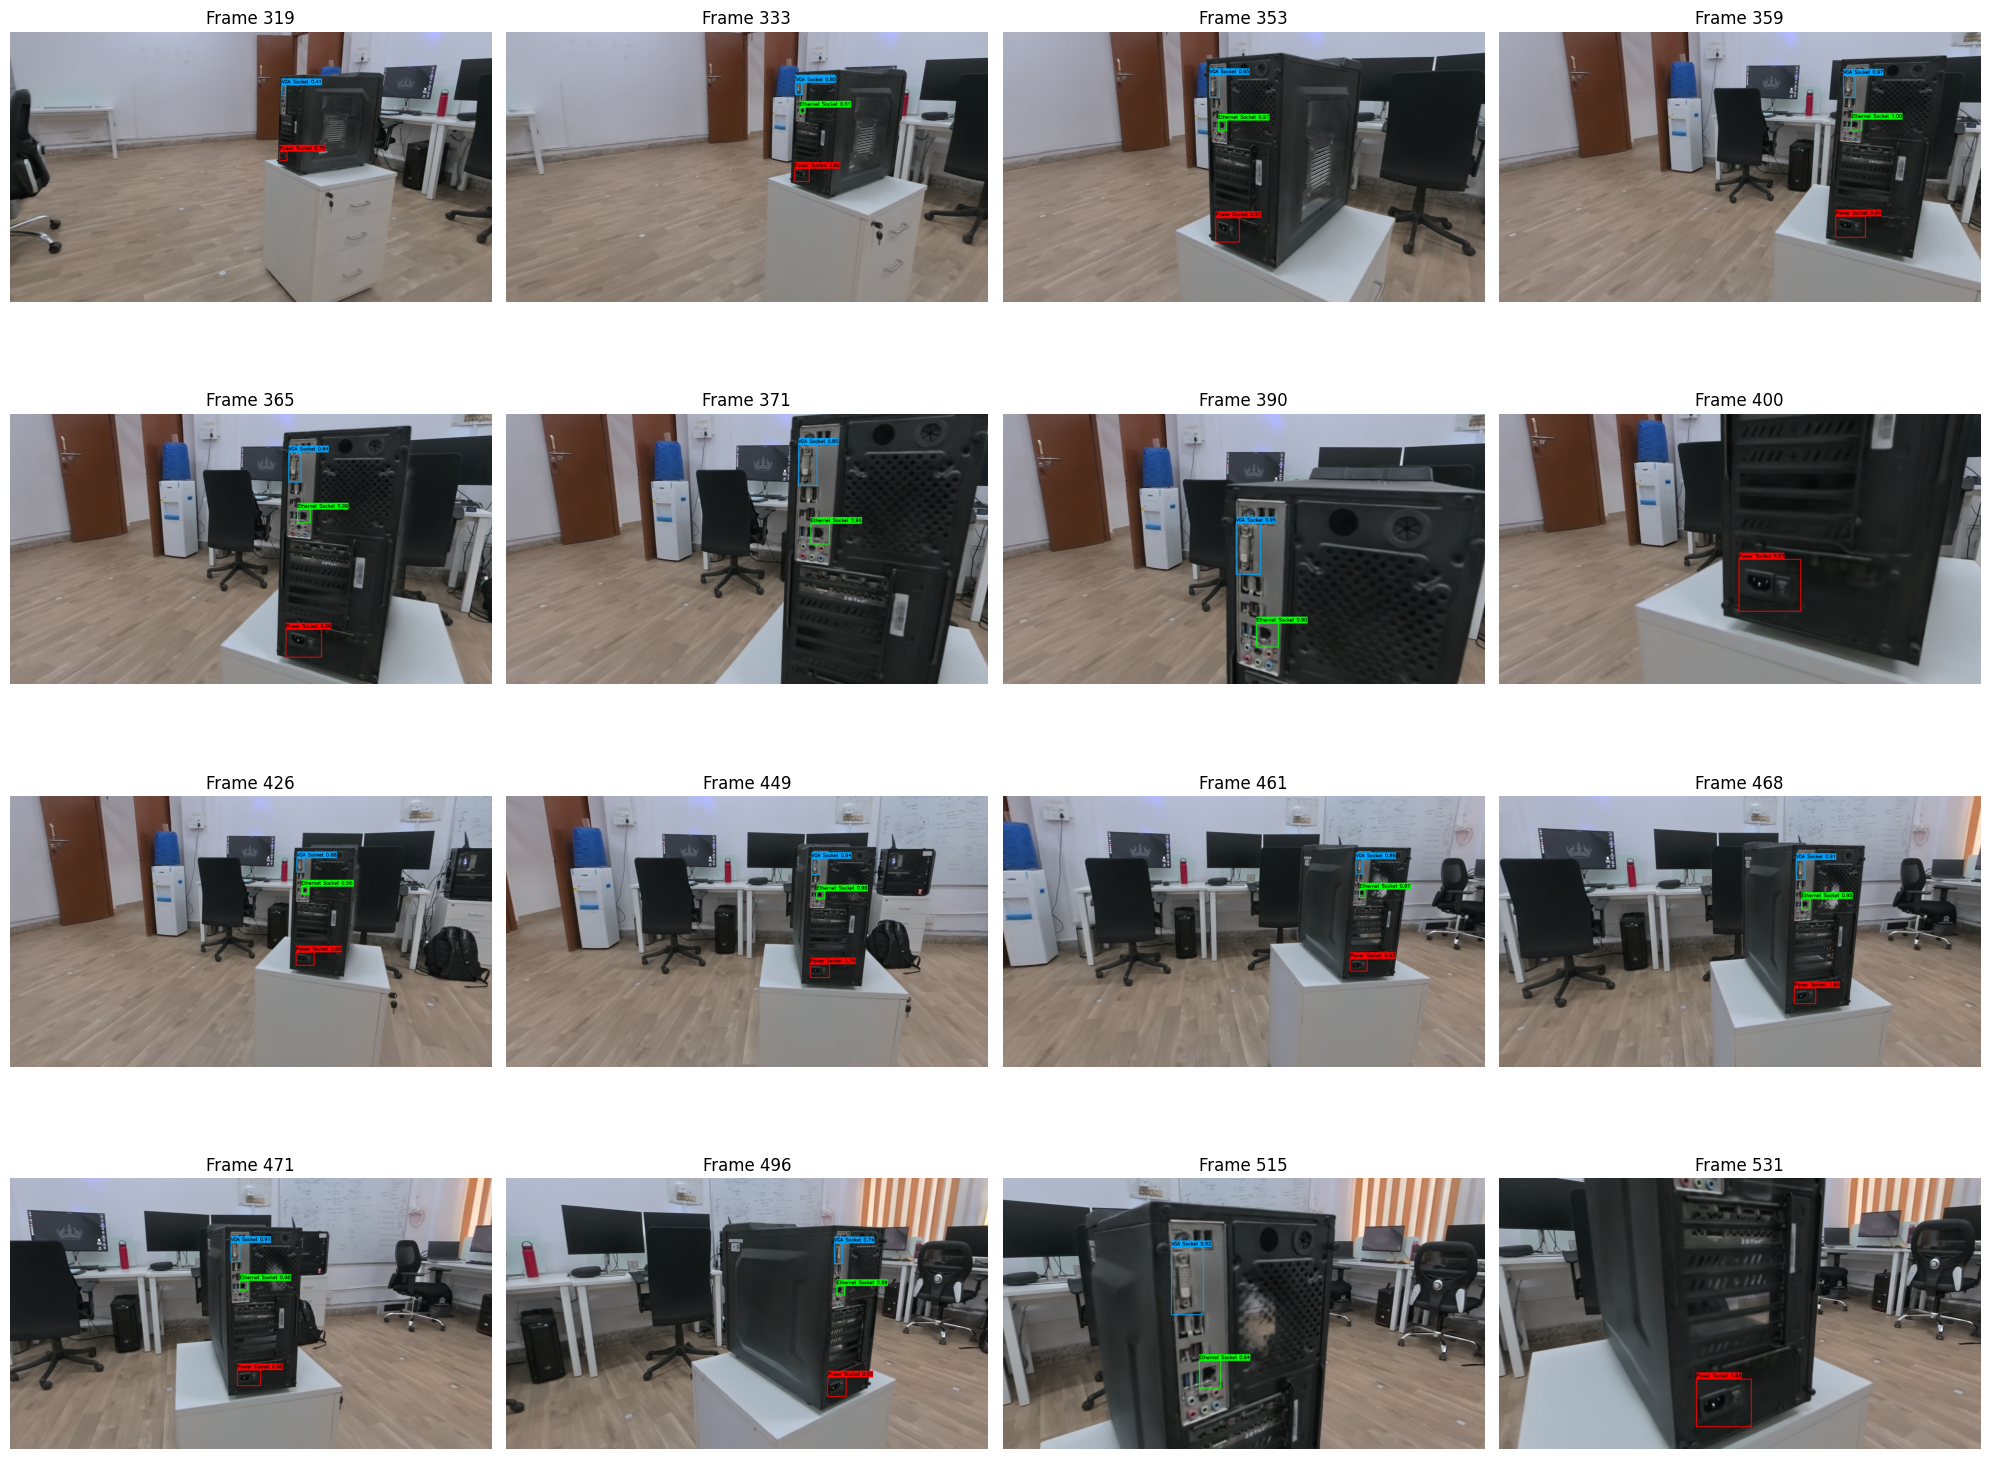

All visualizations saved to: /kaggle/working/visualized_detections
You can download the folder from the right sidebar → Files → visualized_detections


In [6]:
import cv2
import matplotlib.pyplot as plt
import os
from glob import glob
VIS_DIR = "/kaggle/working/visualized_detections"
os.makedirs(VIS_DIR, exist_ok=True)

CLASS_NAMES = {
    0: "Ethernet Socket",
    1: "Power Socket",
    2: "VGA Socket"
}
COLORS = {0: (0, 255, 0), 1: (0, 0, 255), 2: (255, 165, 0)} 
IMG_SOURCE_DIR = "/kaggle/input/datasets/bodduamarnath2004/datasetrp"
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()
print("Creating visualizations...")
for idx, (frame_id, boxes) in enumerate(detections.items()):
    img_path = os.path.join(IMG_SOURCE_DIR, f"frame_{str(frame_id).zfill(6)}.png")
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        continue
    img = cv2.imread(img_path)
    img_draw = img.copy()
    for box in boxes:
        x1, y1, x2, y2, cls_id, conf = box
        color = COLORS.get(cls_id, (255, 255, 255))
        label = f"{CLASS_NAMES.get(cls_id, 'Unknown')} {conf:.2f}"
        cv2.rectangle(img_draw, (int(x1), int(y1)), (int(x2), int(y2)), color, 3)
        text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)[0]
        cv2.rectangle(img_draw, (int(x1), int(y1)-35), (int(x1)+text_size[0], int(y1)), color, -1)
        cv2.putText(img_draw, label, (int(x1), int(y1)-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
    
    save_path = os.path.join(VIS_DIR, f"frame_{str(frame_id).zfill(6)}_detected.png")
    cv2.imwrite(save_path, img_draw)
    if idx < 16:
        rgb_img = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(rgb_img)
        axes[idx].set_title(f"Frame {frame_id}")
        axes[idx].axis('off')
plt.tight_layout()
plt.show()

print(f"All visualizations saved to: {VIS_DIR}")
print(f"You can download the folder from the right sidebar → Files → visualized_detections")

In [7]:
import numpy as np
import json, os, glob as _glob

DATASET_DIR = "/kaggle/input/datasets/bodduamarnath2004/datasetrp"
POSES_FILE  = os.path.join(DATASET_DIR, "poses.json")    
IMG_W, IMG_H = 2560, 1440
fx, fy = 1477.00974684544, 1480.4424455584467
cx, cy = 1298.2501500778505, 686.8201623541711
K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=float)
with open(POSES_FILE) as f:
    poses_raw = json.load(f)
poses = {} 
for k, v in poses_raw.items():
    mat = np.array(v, dtype=float)
    if mat.shape == (3, 4):
        mat = np.vstack([mat, [0, 0, 0, 1]])
    poses[int(k)] = mat

CLS_TO_ENTITY = {0: "ethernet_socket", 1: "power_socket", 2: "vga_socket"}
ENTITY_LIST   = ["vga_socket", "ethernet_socket", "power_socket"]
print(f"  Intrinsics : fx={fx:.1f}  fy={fy:.1f}  cx={cx:.1f}  cy={cy:.1f}")
print(f"  Poses loaded : {len(poses)}")
print(f"  Image size   : {IMG_W}×{IMG_H}")
frame_files = sorted(_glob.glob(os.path.join(DATASET_DIR, "frame_*.png")))
missing = [f for f in frame_files
           if int(os.path.basename(f).replace("frame_","").replace(".png","")) not in poses]
print(f"  Dataset frames : {len(frame_files)}")
print(f"  Missing poses  : {len(missing)} {'' if not missing else ' ' + str(missing)}")


  Intrinsics : fx=1477.0  fy=1480.4  cx=1298.3  cy=686.8
  Poses loaded : 704
  Image size   : 2560×1440
  Dataset frames : 16
  Missing poses  : 0 


In [8]:
CONF_THRESH = 0.25  
det3d = {e: [] for e in ENTITY_LIST}
missing_poses_count = 0
for frame_id, boxes in detections.items():
    if frame_id not in poses:
        missing_poses_count += 1
        continue
    T_cw     = poses[frame_id]
    img_path = os.path.join(DATASET_DIR, f"frame_{str(frame_id).zfill(6)}.png")
    for box in boxes:
        x1, y1, x2, y2, cls_id, conf = box
        if float(conf) < CONF_THRESH:
            continue
        entity = CLS_TO_ENTITY.get(int(cls_id))
        if entity is None:
            continue
        det3d[entity].append({
            "box"  : [float(x1), float(y1), float(x2), float(y2)],
            "T_cw" : T_cw,
            "score": float(conf),
            "path" : img_path,
        })

print(f"  CONF_THRESH = {CONF_THRESH}")
if missing_poses_count:
    print(f"   {missing_poses_count} frames had no pose entry")
print()
print("  Detections per entity:")
for e in ENTITY_LIST:
    n   = len(det3d[e])
    avg = np.mean([d["score"] for d in det3d[e]]) if n else 0.0
    ok  = "yes" if n >= 2 else "no  need ≥2 — lower CONF_THRESH"
    print(f"    {e:<22}: {n:3d} frames   avg_conf={avg:.2f}   {ok}")

  CONF_THRESH = 0.25

  Detections per entity:
    vga_socket            :  15 frames   avg_conf=0.85   yes
    ethernet_socket       :  14 frames   avg_conf=0.88   yes
    power_socket          :  13 frames   avg_conf=0.81   yes


In [9]:
def triangulate_rays(origins, directions):
    A = np.zeros((3, 3))
    b = np.zeros(3)
    for o, d in zip(origins, directions):
        d = d / np.linalg.norm(d)
        M = np.eye(3) - np.outer(d, d)
        A += M
        b += M @ o
    return np.linalg.lstsq(A, b, rcond=None)[0]

def triangulate_entity(dets):
    origins, dirs = [], []
    for det in dets:
        box = det["box"]
        u = (box[0] + box[2]) / 2.0 
        v = (box[1] + box[3]) / 2.0
        d_cam = np.array([(u - cx)/fx, (v - cy)/fy, 1.0])
        d_cam /= np.linalg.norm(d_cam)
        R_cw  = det["T_cw"][:3, :3]
        t_cw  = det["T_cw"][:3,  3]
        origins.append(t_cw)
        dirs.append(R_cw @ d_cam)
    if len(origins) < 2:
        return None
    return triangulate_rays(origins, dirs)

print("=== Multi-view Triangulation ===")
tri_centers = {}
for entity in ENTITY_LIST:
    c = triangulate_entity(det3d[entity])
    tri_centers[entity] = c
    if c is not None:
        print(f"  {entity:<22}: [{c[0]:.4f}, {c[1]:.4f}, {c[2]:.4f}]")
    else:
        print(f"  {entity:<22}: ❌  (need ≥2 detections)")

VGA_GT_C = np.array([0.2704921202927293, 0.2261220732082181, 0.8349008829378597])
if tri_centers.get("vga_socket") is not None:
    err = np.linalg.norm(tri_centers["vga_socket"] - VGA_GT_C)
    grade = " good" if err < 0.08 else "no check detections"
    print(f"\n  VGA vs sample-answer centre error: {err*100:.1f} cm  {grade}")

=== Multi-view Triangulation ===
  vga_socket            : [0.2721, 0.2273, 0.8333]
  ethernet_socket       : [0.2905, 0.2291, 0.7557]
  power_socket          : [0.3012, 0.2260, 0.5240]

  VGA vs sample-answer centre error: 0.3 cm   good


In [10]:
def estimate_panel_normal(dets, center_3d):
    dirs = []
    for det in dets:
        cam_pos = det["T_cw"][:3, 3]
        v = cam_pos - center_3d
        n = np.linalg.norm(v)
        if n > 0.01:
            dirs.append(v / n)
    if not dirs:
        return np.array([0.0, 0.0, -1.0])
    mean_dir = np.mean(dirs, axis=0)
    norm = np.linalg.norm(mean_dir)
    return mean_dir / norm if norm > 1e-6 else np.array([0.0, 0.0, -1.0])

def build_panel_rotation(normal, world_up=np.array([0.0, 1.0, 0.0])):
    n = normal / np.linalg.norm(normal)
    up = world_up - np.dot(world_up, n) * n
    if np.linalg.norm(up) < 1e-6:
        up = np.array([0.0, 0.0, 1.0])
        up -= np.dot(up, n) * n
    up /= np.linalg.norm(up)
    right = np.cross(up, n)
    right /= np.linalg.norm(right)
    R = np.column_stack([right, up, n])
    if np.linalg.det(R) < 0:
        R[:, 0] *= -1
    return R

def estimate_extent_from_bbox(dets, center_3d):
    widths, heights = [], []
    for det in dets:
        dist = float(np.linalg.norm(center_3d - det["T_cw"][:3, 3]))
        if not (0.1 < dist < 15.0):
            continue
        box = det["box"]
        w_m = (box[2] - box[0]) * dist / fx
        h_m = (box[3] - box[1]) * dist / fy
        if 0.001 < w_m < 0.30 and 0.001 < h_m < 0.20:
            widths.append(w_m)
            heights.append(h_m)
    if not widths:
        return None, None
    return float(np.median(widths)), float(np.median(heights))

PHYS_PRIOR = {
    "vga_socket"      : {"wh": (0.0354, 0.0118), "depth": 0.0061},
    "ethernet_socket" : {"wh": (0.016,  0.013 ), "depth": 0.018 },
    "power_socket"    : {"wh": (0.028,  0.022 ), "depth": 0.020 },
}
print("Section D — helpers defined")

Section D — helpers defined


In [11]:
WORLD_UP = np.array([0.0, 1.0, 0.0])  
entity_obbs = {}
print("=== Final OBBs ===\n")
for entity in ENTITY_LIST:
    print(f"── {entity} ──")
    dets   = det3d.get(entity, [])
    center = tri_centers.get(entity)
    if center is None:
        print("   No triangulated centre — using placeholder\n")
        entity_obbs[entity] = None
        continue
    normal = estimate_panel_normal(dets, center)
    R      = build_panel_rotation(normal, WORLD_UP)
    w_m, h_m = estimate_extent_from_bbox(dets, center)
    prior     = PHYS_PRIOR[entity]
    if w_m is None:
        w_m, h_m = prior["wh"]
        print("  Extent fallback → physical prior")
    else:
        w_m = min(w_m, prior["wh"][0] * 2.5)
        h_m = min(h_m, prior["wh"][1] * 2.5)
    depth_m = prior["depth"]
    extent  = [float(w_m), float(h_m), float(depth_m)]
    entity_obbs[entity] = {
        "center"  : center.tolist(),
        "extent"  : extent,
        "rotation": R.tolist(),
    }

    print(f"  center : [{center[0]:.5f}, {center[1]:.5f}, {center[2]:.5f}]")
    print(f"  extent : [{w_m:.5f}, {h_m:.5f}, {depth_m:.5f}]")
    print(f"  normal : [{normal[0]:.3f}, {normal[1]:.3f}, {normal[2]:.3f}]")
    print(f"  frames : {len(dets)}\n")

print("=== VGA Validation vs sample_answers.json ===")
VGA_GT = {
    "center"  : [0.2704921202927293, 0.2261220732082181, 0.8349008829378597],
    "extent"  : [0.03537766175069747, 0.011822199241650923, 0.0061316691090621735],
    "rotation": [[-0.004004375172752437, 0.9672545151126772, -0.25377680739897346],
                 [ 0.01584254528462312,  0.25380835519540434, 0.9671247761234889],
                 [ 0.9998664804554559,  -0.00014774012094266402, -0.016340117333610394]],
}
vga = entity_obbs.get("vga_socket")
if vga:
    c_err   = float(np.linalg.norm(np.array(vga["center"]) - np.array(VGA_GT["center"])))
    R1, R2  = np.array(vga["rotation"]), np.array(VGA_GT["rotation"])
    cos_    = np.clip((np.trace(R1.T @ R2) - 1) / 2, -1, 1)
    rot_err = float(np.degrees(np.arccos(cos_)))
    grade   = ("Excellent" if c_err < 0.03 else
               "Good"      if c_err < 0.06 else
               "Fair"     if c_err < 0.10 else "Poor")
    print(f"  Centre error   : {c_err*100:.2f} cm   {grade}")
    print(f"  Rotation error : {rot_err:.1f}°")
    if c_err > 0.08:
        print("Tip: lower CONF_THRESH to 0.15 in Cell B and re-run")
else:
    print("VGA not computed")

=== Final OBBs ===

── vga_socket ──
  center : [0.27213, 0.22728, 0.83334]
  extent : [0.02134, 0.02950, 0.00610]
  normal : [0.191, -0.980, 0.047]
  frames : 15

── ethernet_socket ──
  center : [0.29054, 0.22906, 0.75569]
  extent : [0.02012, 0.02297, 0.01800]
  normal : [0.057, -0.975, 0.213]
  frames : 14

── power_socket ──
  center : [0.30124, 0.22596, 0.52396]
  extent : [0.05973, 0.04849, 0.02000]
  normal : [0.082, -0.876, 0.475]
  frames : 13

=== VGA Validation vs sample_answers.json ===
  Centre error   : 0.25 cm   Excellent
  Rotation error : 177.8°


In [12]:
import json
OUTPUT_ENTITIES = ["vga_socket", "ethernet_socket", "power_socket"]

def clean_obb(obb, entity):
    if obb is None:
        print(f" {entity}: using zero placeholder — improve detection first!")
        return {
            "center"  : [0.0, 0.0, 0.0],
            "extent"  : [0.01, 0.01, 0.01],
            "rotation": [[1,0,0],[0,1,0],[0,0,1]],
        }
    return {
        "center"  : [round(v, 10) for v in obb["center"]],
        "extent"  : [round(v, 10) for v in obb["extent"]],
        "rotation": [[round(v, 10) for v in row] for row in obb["rotation"]],
    }

output = [{"entity": e, "obb": clean_obb(entity_obbs.get(e), e)}
          for e in OUTPUT_ENTITIES]

OUT_PATH = "/kaggle/working/final_answers.json"
with open(OUT_PATH, "w") as f:
    json.dump(output, f, indent=2)

# Strict format check
with open(OUT_PATH) as f:
    v = json.load(f)
assert len(v) == 3
for entry in v:
    assert set(entry.keys()) == {"entity", "obb"}
    obb = entry["obb"]
    assert len(obb["center"]) == 3
    assert len(obb["extent"]) == 3
    assert len(obb["rotation"]) == 3
    for row in obb["rotation"]:
        assert len(row) == 3

print(f" Saved & verified: {OUT_PATH}")
print()
print(json.dumps(output, indent=2))


 Saved & verified: /kaggle/working/final_answers.json

[
  {
    "entity": "vga_socket",
    "obb": {
      "center": [
        0.2721291613,
        0.2272775264,
        0.8333377432
      ],
      "extent": [
        0.0213395627,
        0.0295,
        0.0061
      ],
      "rotation": [
        [
          0.2400929663,
          0.9517431731,
          0.1911551724
        ],
        [
          0.0,
          0.1969149546,
          -0.9804205734
        ],
        [
          -0.9707498996,
          0.2353920836,
          0.0472778955
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.2905382017,
        0.2290627555,
        0.7556919293
      ],
      "extent": [
        0.0201241875,
        0.0229669527,
        0.018
      ],
      "rotation": [
        [
          0.9660911767,
          0.2518569574,
          0.0568850705
        ],
        [
          0.0,
          0.2203129949,
          -0.9754292308
       

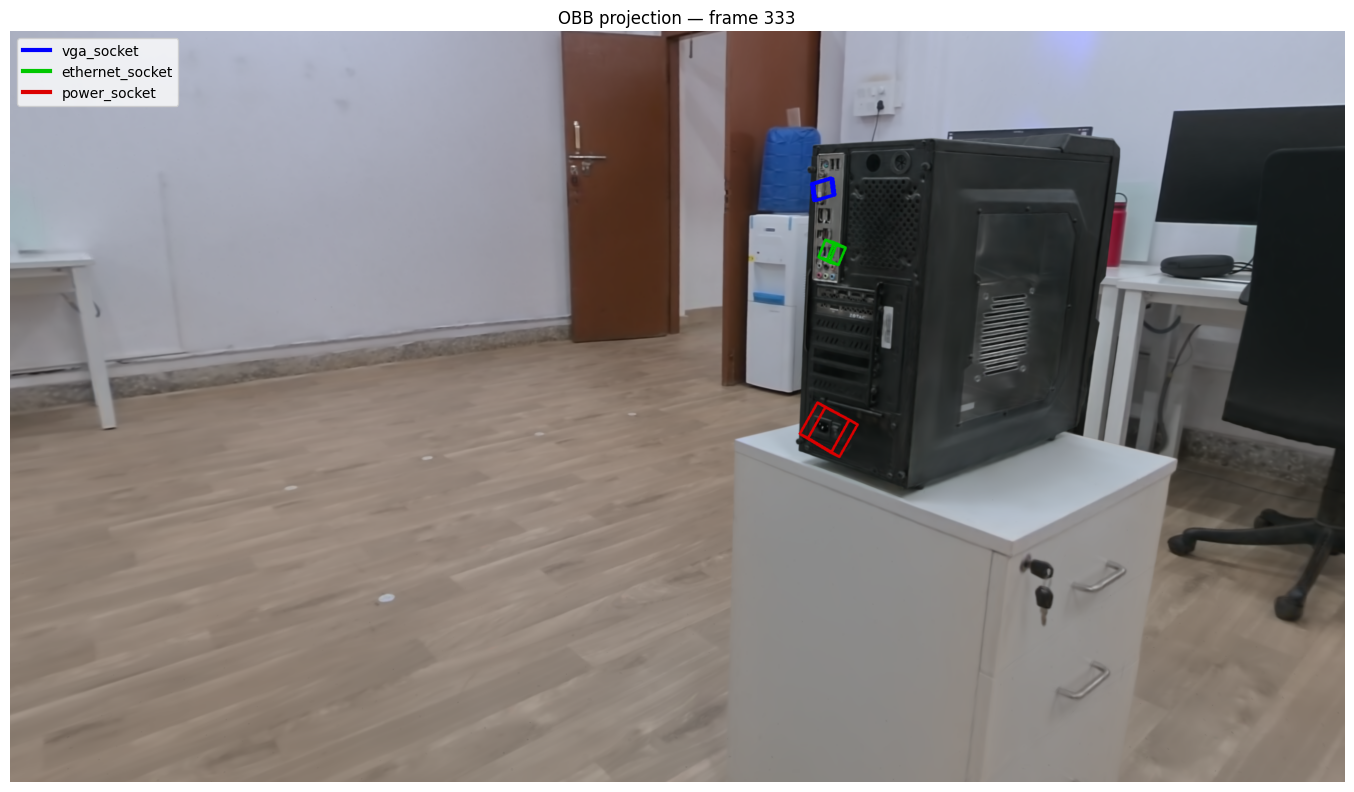

Saved: /kaggle/working/obb_projection.png


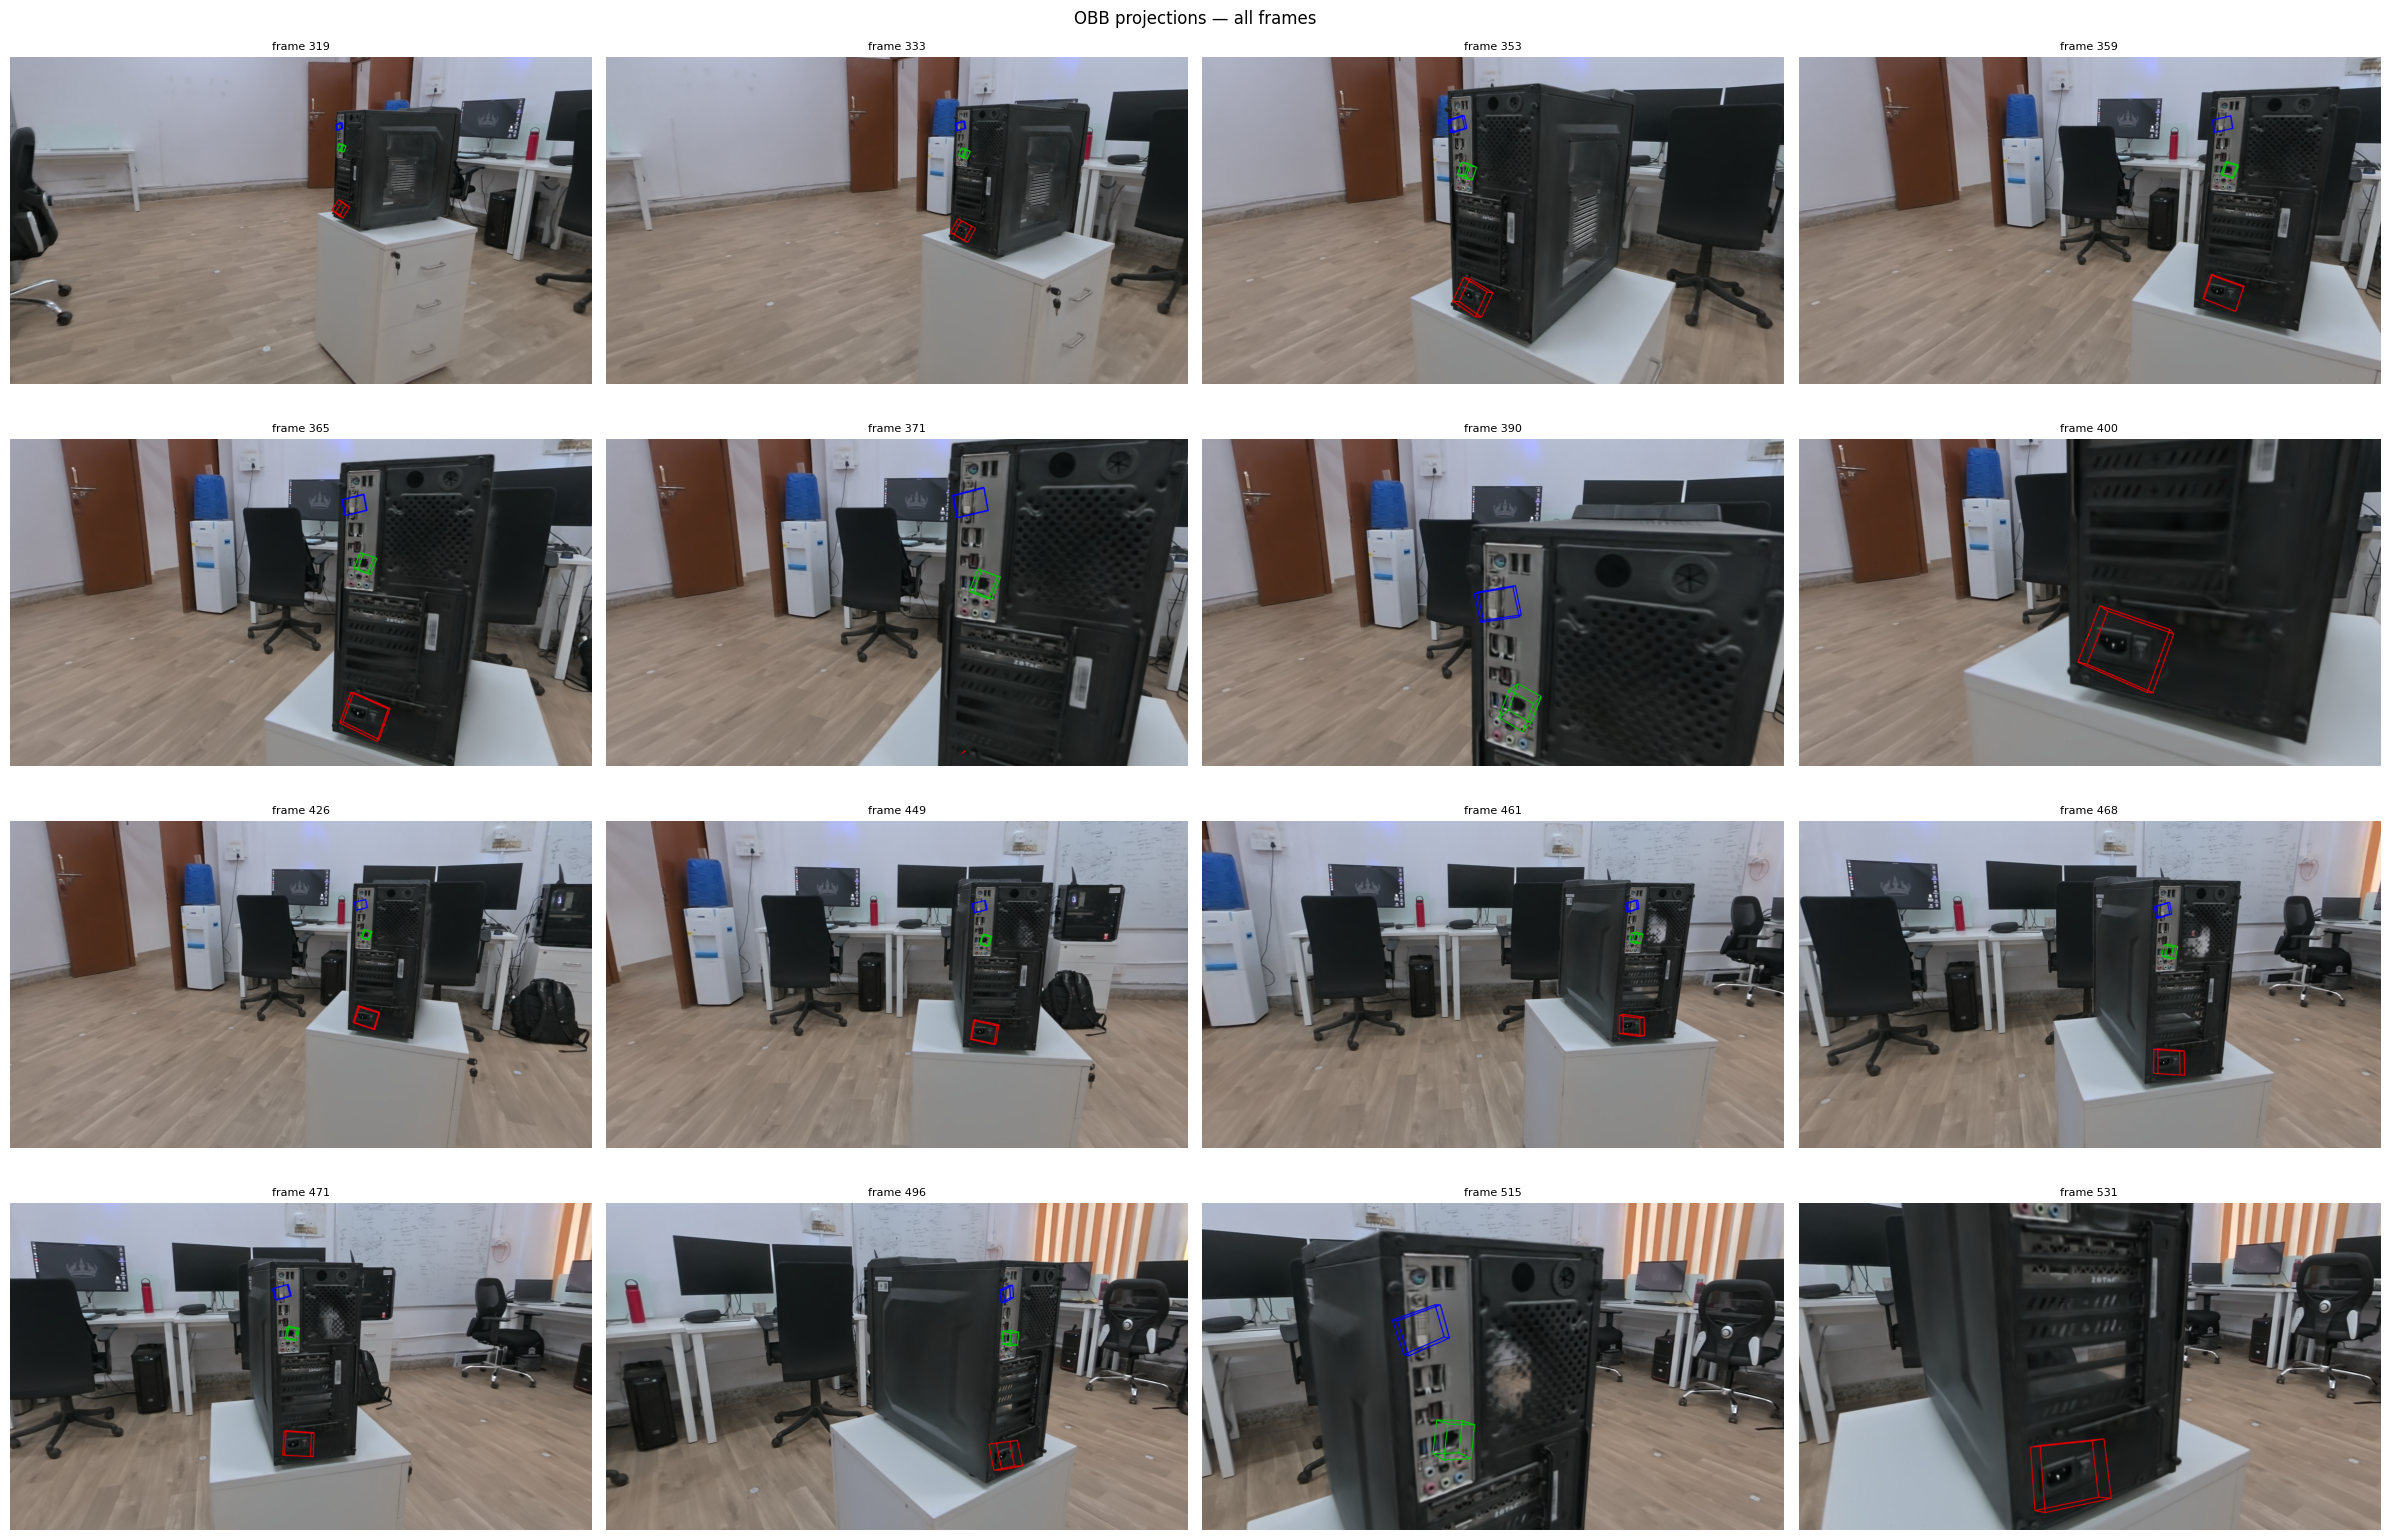

Saved: /kaggle/working/obb_all_frames.png


In [13]:
import cv2, glob as _glob
import matplotlib.pyplot as plt
from PIL import Image
def obb_corners_world(obb):
    c = np.array(obb["center"])
    e = np.array(obb["extent"]) / 2
    R = np.array(obb["rotation"])
    signs = np.array([[-1,-1,-1],[1,-1,-1],[1,1,-1],[-1,1,-1],
                      [-1,-1, 1],[1,-1, 1],[1, 1, 1],[-1, 1, 1]])
    return (R @ (signs * e).T).T + c

EDGES = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),
         (0,4),(1,5),(2,6),(3,7)]
COLORS = {"vga_socket":(0,0,255), "ethernet_socket":(0,200,0), "power_socket":(220,0,0)}

def draw_obb(img, obb, T_cw, color, thick=3):
    if obb is None:
        return img
    corners = obb_corners_world(obb)
    T_wc    = np.linalg.inv(T_cw)
    ch      = np.hstack([corners, np.ones((8,1))])
    cc      = (T_wc @ ch.T).T
    if np.any(cc[:,2] <= 0):
        return img
    u  = K[0,0]*cc[:,0]/cc[:,2] + K[0,2]
    v_ = K[1,1]*cc[:,1]/cc[:,2] + K[1,2]
    pts = np.stack([u, v_], axis=1).astype(int)
    out = img.copy()
    for i, j in EDGES:
        p1, p2 = tuple(pts[i]), tuple(pts[j])
        if (0<=p1[0]<IMG_W and 0<=p1[1]<IMG_H and
            0<=p2[0]<IMG_W and 0<=p2[1]<IMG_H):
            cv2.line(out, p1, p2, color, thick)
    return out

score_map = {}
for dets in det3d.values():
    for d in dets:
        score_map[d["path"]] = score_map.get(d["path"], 0) + d["score"]

all_frames = sorted(_glob.glob(os.path.join(DATASET_DIR, "frame_*.png")))
best_path  = max(score_map, key=score_map.get) if score_map else all_frames[0]
best_fid   = int(os.path.basename(best_path).replace("frame_","").replace(".png",""))
img_best   = np.array(Image.open(best_path).convert("RGB"))

for ent in OUTPUT_ENTITIES:
    img_best = draw_obb(img_best, entity_obbs.get(ent), poses[best_fid], COLORS.get(ent, (180,180,180)))

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img_best)
legend = [plt.Line2D([0],[0], color=np.array(c)/255, lw=3, label=e)
          for e, c in COLORS.items()]
ax.legend(handles=legend, fontsize=10, loc="upper left")
ax.set_title(f"OBB projection — frame {best_fid}", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/obb_projection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /kaggle/working/obb_projection.png")

n = len(all_frames)
nc = 4; nr = (n + nc - 1) // nc
fig2, axes = plt.subplots(nr, nc, figsize=(6*nc, 4*nr))
axes = np.array(axes).flatten()
for ax in axes: ax.axis("off")

for i, fp in enumerate(all_frames):
    fid = int(os.path.basename(fp).replace("frame_","").replace(".png",""))
    if fid not in poses: continue
    img = np.array(Image.open(fp).convert("RGB"))
    for ent in OUTPUT_ENTITIES:
        img = draw_obb(img, entity_obbs.get(ent), poses[fid], COLORS.get(ent))
    axes[i].imshow(img)
    axes[i].set_title(f"frame {fid}", fontsize=8)

plt.suptitle("OBB projections — all frames", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/obb_all_frames.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: /kaggle/working/obb_all_frames.png")


Image loaded: 490×840 (Screenshot 2026-05-04 at 2.43.40AM.png)

Running YOLO detection...

0: 640x384 1 Ethernet Socket, 1 Power Socket, 1 VGA Socket, 27.2ms
Speed: 2.4ms preprocess, 27.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

Detected entities (conf > 0.25):
 vga_socket             conf=0.922 box=[65,92,109,188]
 ethernet_socket        conf=0.914 box=[89,269,128,315]
 power_socket           conf=0.913 box=[30,646,149,736]

Building output JSON...
 vga_socket            :  detected → using 3D OBB
 ethernet_socket       :  detected → using 3D OBB
 power_socket          :  detected → using 3D OBB

 Saved & verified: /kaggle/working/final_answers_new_image.json


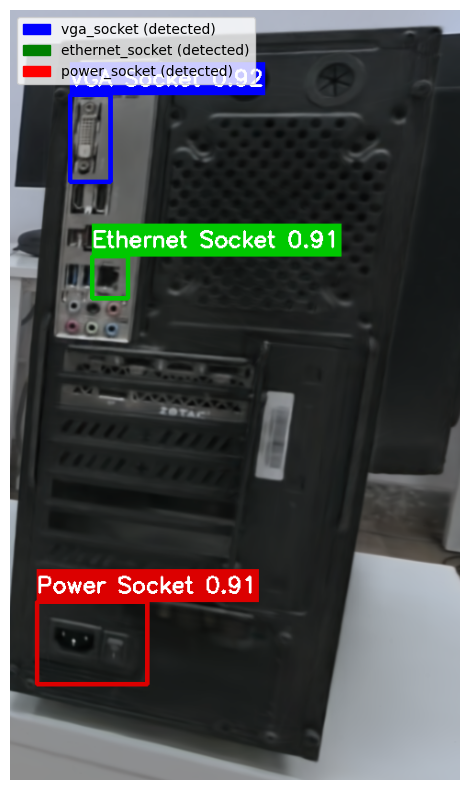

Visualization saved: /kaggle/working/new_image_prediction.png

 FINAL OUTPUT JSON
[
  {
    "entity": "vga_socket",
    "obb": {
      "center": [
        0.2721291613,
        0.2272775264,
        0.8333377432
      ],
      "extent": [
        0.0213395627,
        0.0295,
        0.0061
      ],
      "rotation": [
        [
          0.2400929663,
          0.9517431731,
          0.1911551724
        ],
        [
          0.0,
          0.1969149546,
          -0.9804205734
        ],
        [
          -0.9707498996,
          0.2353920836,
          0.0472778955
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.2905382017,
        0.2290627555,
        0.7556919293
      ],
      "extent": [
        0.0201241875,
        0.0229669527,
        0.018
      ],
      "rotation": [
        [
          0.9660911767,
          0.2518569574,
          0.0568850705
        ],
        [
          0.0,
          0.2203129949,
    

In [21]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os
NEW_IMAGE_PATH = "/kaggle/input/datasets/bodduamarnath2004/sample1/Screenshot 2026-05-04 at 2.43.40AM.png"
OUTPUT_JSON = "/kaggle/working/final_answers_new_image.json"
CONF_THRESH = 0.25
CLS_TO_ENTITY = {0: "ethernet_socket", 1: "power_socket", 2: "vga_socket"}
ENTITY_LIST = ["vga_socket", "ethernet_socket", "power_socket"]
VIS_COLORS = {
    "vga_socket": (0, 0, 255),
    "ethernet_socket": (0, 200, 0),
    "power_socket": (220, 0, 0),
}
LABEL_COLORS = {
    "vga_socket": "blue",
    "ethernet_socket": "green",
    "power_socket": "red",
}

CLASS_NAMES = {0: "Ethernet Socket", 1: "Power Socket", 2: "VGA Socket"}
assert os.path.exists(NEW_IMAGE_PATH), f"Image not found: {NEW_IMAGE_PATH}"
img_bgr = cv2.imread(NEW_IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W = img_bgr.shape[:2]
print(f"Image loaded: {W}×{H} ({os.path.basename(NEW_IMAGE_PATH)})")
assert 'model' in globals(), "ERROR: 'model' (YOLO model) is not defined. Load it in a previous cell."
assert 'entity_obbs' in globals(), "ERROR: 'entity_obbs' (3D OBB dictionary) is not defined. Compute it in a previous cell."
print("\nRunning YOLO detection...")
yolo_results = model(img_bgr)[0]
new_detections = {}
img_draw = img_rgb.copy()
for box in yolo_results.boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    cls_id = int(box.cls[0].cpu().numpy())
    conf = float(box.conf[0].cpu().numpy())
    entity = CLS_TO_ENTITY.get(cls_id)
    if conf < CONF_THRESH or entity is None:
        continue
    if entity not in new_detections or conf > new_detections[entity]["conf"]:
        new_detections[entity] = {
            "box": [float(x1), float(y1), float(x2), float(y2)],
            "conf": conf,
        }
    color = VIS_COLORS.get(entity, (180, 180, 180))
    label = f"{CLASS_NAMES.get(cls_id)} {conf:.2f}"
    cv2.rectangle(img_draw, (int(x1), int(y1)), (int(x2), int(y2)), color, 3)
    tsz = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)[0]
    cv2.rectangle(img_draw, (int(x1), int(y1) - 35),
                  (int(x1) + tsz[0], int(y1)), color, -1)
    cv2.putText(img_draw, label, (int(x1), int(y1) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

print(f"\nDetected entities (conf > {CONF_THRESH}):")
for ent in ENTITY_LIST:
    if ent in new_detections:
        d = new_detections[ent]
        b = d["box"]
        print(f" {ent:<22} conf={d['conf']:.3f} "
              f"box=[{b[0]:.0f},{b[1]:.0f},{b[2]:.0f},{b[3]:.0f}]")
    else:
        print(f" {ent:<22} not detected")

print("\nBuilding output JSON...")
def clean_obb(obb):
    if obb is None:
        return {
            "center": [0.0, 0.0, 0.0],
            "extent": [0.01, 0.01, 0.01],
            "rotation": [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
        }
    return {
        "center": [round(v, 10) for v in obb["center"]],
        "extent": [round(v, 10) for v in obb["extent"]],
        "rotation": [[round(v, 10) for v in row] for row in obb["rotation"]],
    }

output = []
for entity in ENTITY_LIST:
    obb_3d = entity_obbs.get(entity)
    if entity in new_detections:
        entry_obb = clean_obb(obb_3d)
        status = " detected → using 3D OBB"
    else:
        entry_obb = clean_obb(None)
        status = " not detected → placeholder"
    output.append({"entity": entity, "obb": entry_obb})
    print(f" {entity:<22}: {status}")

with open(OUTPUT_JSON, "w") as f:
    json.dump(output, f, indent=2)

with open(OUTPUT_JSON) as f:
    v = json.load(f)
assert len(v) == 3
for entry in v:
    assert set(entry.keys()) == {"entity", "obb"}
    assert len(entry["obb"]["center"]) == 3
    assert len(entry["obb"]["extent"]) == 3
    assert len(entry["obb"]["rotation"]) == 3
    for row in entry["obb"]["rotation"]:
        assert len(row) == 3

print(f"\n Saved & verified: {OUTPUT_JSON}")
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
ax.imshow(img_draw)

legend_patches = [
    mpatches.Patch(color=LABEL_COLORS[e],
                   label=f"{e} ({'detected' if e in new_detections else 'missing'})")
    for e in ENTITY_LIST
]
ax.legend(handles=legend_patches, fontsize=10, loc="upper left")
ax.axis("off")
plt.tight_layout()
vis_path = "/kaggle/working/new_image_prediction.png"
plt.savefig(vis_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Visualization saved: {vis_path}")
print("\n" + "=" * 55)
print(" FINAL OUTPUT JSON")
print("=" * 55)
print(json.dumps(output, indent=2))

Image loaded: 2560×1440  (frame_000319.png)

Running YOLO detection...

0: 384x640 1 Power Socket, 1 VGA Socket, 28.0ms
Speed: 2.7ms preprocess, 28.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Detected entities (conf > 0.25):
  vga_socket             conf=0.415  box=[1444,287,1465,344]
  ethernet_socket        NOT detected
  power_socket           conf=0.349  box=[1432,641,1472,689]

Finding closest existing frame via ORB feature matching...
  Best matching frame : frame_000319.png
  ORB matches         : 1000
  Pose loaded from poses.json 

Projecting 3D OBB wireframes...
  vga_socket            : projected
  ethernet_socket       : projected
  power_socket          : projected

Building output JSON...
  vga_socket            : detected → using 3D OBB
  ethernet_socket       : not detected → placeholder
  power_socket          : detected → using 3D OBB

Saved & verified: /kaggle/working/final_answers_new_image.json


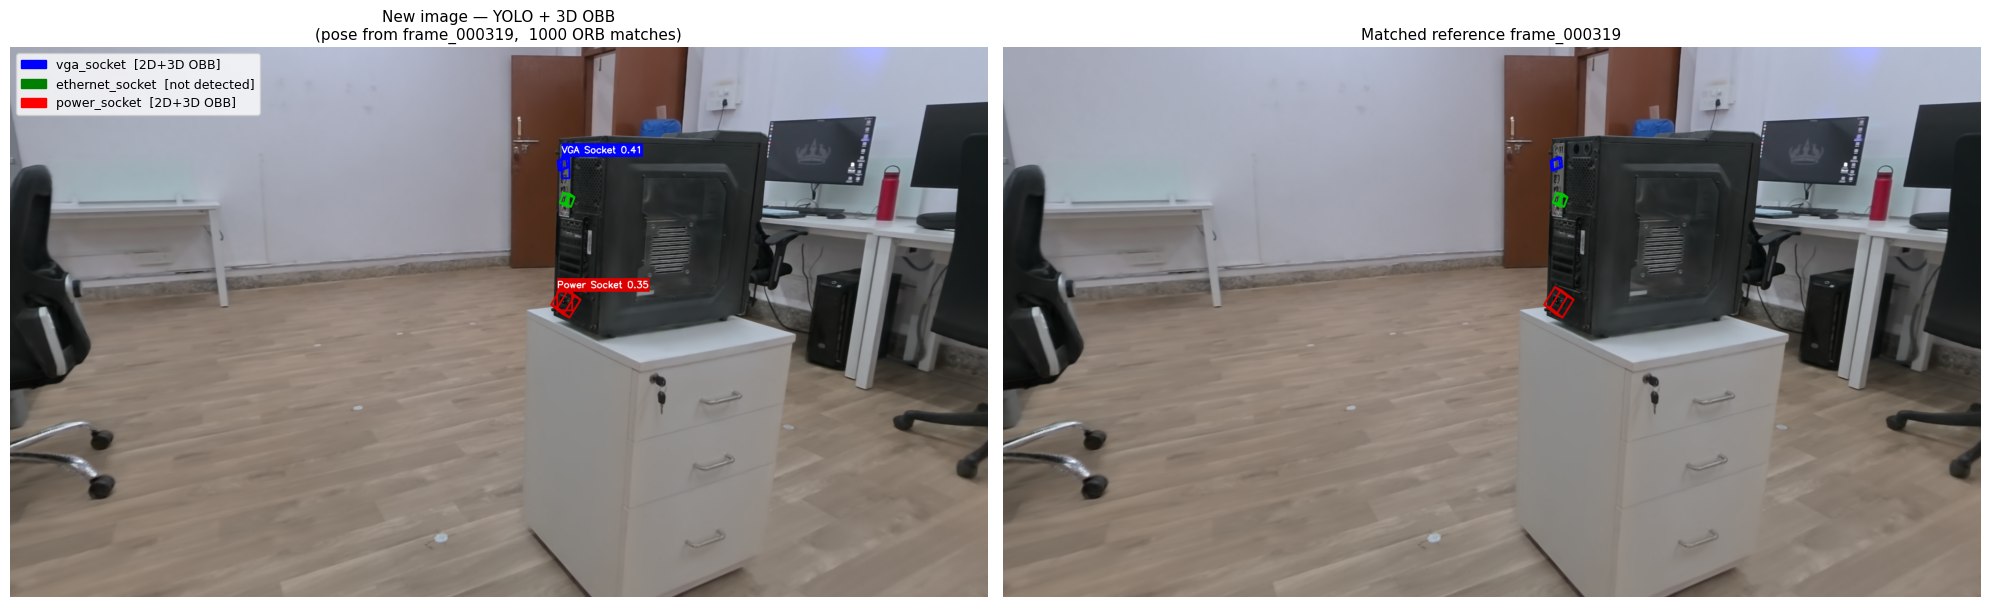

Visualization saved: /kaggle/working/new_image_prediction.png

  FINAL OUTPUT JSON
[
  {
    "entity": "vga_socket",
    "obb": {
      "center": [
        0.2721291613,
        0.2272775264,
        0.8333377432
      ],
      "extent": [
        0.0213395627,
        0.0295,
        0.0061
      ],
      "rotation": [
        [
          0.2400929663,
          0.9517431731,
          0.1911551724
        ],
        [
          0.0,
          0.1969149546,
          -0.9804205734
        ],
        [
          -0.9707498996,
          0.2353920836,
          0.0472778955
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.0,
        0.0,
        0.0
      ],
      "extent": [
        0.01,
        0.01,
        0.01
      ],
      "rotation": [
        [
          1,
          0,
          0
        ],
        [
          0,
          1,
          0
        ],
        [
          0,
          0,
          1
        ]
      ]
    

In [25]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os
import glob as _glob

NEW_IMAGE_PATH = "/kaggle/input/datasets/bodduamarnath2004/datasetrp/frame_000319.png"
OUTPUT_JSON    = "/kaggle/working/final_answers_new_image.json"
CONF_THRESH    = 0.25
CLS_TO_ENTITY = {0: "ethernet_socket", 1: "power_socket", 2: "vga_socket"}
ENTITY_LIST   = ["vga_socket", "ethernet_socket", "power_socket"]
CLASS_NAMES   = {0: "Ethernet Socket", 1: "Power Socket", 2: "VGA Socket"}
VIS_COLORS    = {"vga_socket": (0,0,255), "ethernet_socket": (0,200,0), "power_socket": (220,0,0)}
LABEL_COLORS  = {"vga_socket": "blue",   "ethernet_socket": "green",   "power_socket": "red"}
EDGES = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
OUTPUT_ENTITIES = ["vga_socket", "ethernet_socket", "power_socket"]
assert os.path.exists(NEW_IMAGE_PATH), f"Image not found: {NEW_IMAGE_PATH}"
assert 'model'       in globals(), "ERROR: YOLO model not defined — run training cell first."
assert 'entity_obbs' in globals(), "ERROR: entity_obbs not defined — run OBB cell first."
assert 'K'           in globals(), "ERROR: K (intrinsics) not defined — run pose-loading cell first."
assert 'poses'       in globals(), "ERROR: poses not defined — run pose-loading cell first."
assert 'DATASET_DIR' in globals(), "ERROR: DATASET_DIR not defined — run pose-loading cell first."
img_bgr = cv2.imread(NEW_IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_bgr.shape[:2]
print(f"Image loaded: {W}×{H}  ({os.path.basename(NEW_IMAGE_PATH)})")
print("\nRunning YOLO detection...")
yolo_results   = model(img_bgr)[0]
new_detections = {}
for box in yolo_results.boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    cls_id = int(box.cls[0].cpu().numpy())
    conf   = float(box.conf[0].cpu().numpy())
    entity = CLS_TO_ENTITY.get(cls_id)
    if conf < CONF_THRESH or entity is None:
        continue
    if entity not in new_detections or conf > new_detections[entity]["conf"]:
        new_detections[entity] = {
            "box" : [float(x1), float(y1), float(x2), float(y2)],
            "conf": conf,
        }
print(f"Detected entities (conf > {CONF_THRESH}):")
for ent in ENTITY_LIST:
    if ent in new_detections:
        d, b = new_detections[ent], new_detections[ent]["box"]
        print(f"  {ent:<22} conf={d['conf']:.3f}  box=[{b[0]:.0f},{b[1]:.0f},{b[2]:.0f},{b[3]:.0f}]")
    else:
        print(f"  {ent:<22} NOT detected")
print("\nFinding closest existing frame via ORB feature matching...")
orb                = cv2.ORB_create(nfeatures=1000)
bf                 = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
kp_new, desc_new   = orb.detectAndCompute(img_bgr, None)
best_fid       = None
best_n_matches = 0
all_frame_paths = sorted(_glob.glob(os.path.join(DATASET_DIR, "frame_*.png")))
for fp in all_frame_paths:
    fid = int(os.path.basename(fp).replace("frame_", "").replace(".png", ""))
    if fid not in poses:
        continue
    ref_bgr = cv2.imread(fp)
    if ref_bgr is None:
        continue
    kp_ref, desc_ref = orb.detectAndCompute(ref_bgr, None)
    if desc_ref is None or desc_new is None:
        continue
    matches = bf.match(desc_new, desc_ref)
    if len(matches) > best_n_matches:
        best_n_matches = len(matches)
        best_fid       = fid
if best_fid is not None:
    T_new = poses[best_fid]
    print(f"  Best matching frame : frame_{str(best_fid).zfill(6)}.png")
    print(f"  ORB matches         : {best_n_matches}")
    print("  Pose loaded from poses.json ")
else:
    T_new = None
    print("  No matching frame found — OBB wireframes will be skipped ")

def obb_corners_world(obb):
    c     = np.array(obb["center"])
    e     = np.array(obb["extent"]) / 2
    R     = np.array(obb["rotation"])
    signs = np.array([[-1,-1,-1],[1,-1,-1],[1,1,-1],[-1,1,-1],
                      [-1,-1, 1],[1,-1, 1],[1, 1, 1],[-1, 1, 1]])
    return (R @ (signs * e).T).T + c

def draw_obb_on_image(img, obb, T_cw, color, img_w, img_h, thick=3):
    if obb is None or T_cw is None:
        return img
    corners = obb_corners_world(obb)
    T_wc    = np.linalg.inv(T_cw)
    ch      = np.hstack([corners, np.ones((8, 1))])
    cc      = (T_wc @ ch.T).T
    if np.any(cc[:, 2] <= 0):
        return img
    u   = K[0,0] * cc[:,0] / cc[:,2] + K[0,2]
    v_  = K[1,1] * cc[:,1] / cc[:,2] + K[1,2]
    pts = np.stack([u, v_], axis=1).astype(int)
    out = img.copy()
    for i, j in EDGES:
        p1, p2 = tuple(pts[i]), tuple(pts[j])
        if (0<=p1[0]<img_w and 0<=p1[1]<img_h and
            0<=p2[0]<img_w and 0<=p2[1]<img_h):
            cv2.line(out, p1, p2, color, thick)
    return out

img_draw = img_rgb.copy()
for entity, det in new_detections.items():
    b      = det["box"]
    conf   = det["conf"]
    cls_id = next(k for k, v in CLS_TO_ENTITY.items() if v == entity)
    color  = VIS_COLORS.get(entity, (180, 180, 180))
    label  = f"{CLASS_NAMES[cls_id]} {conf:.2f}"
    cv2.rectangle(img_draw, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), color, 3)
    tsz = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)[0]
    cv2.rectangle(img_draw,
                  (int(b[0]), int(b[1]) - 35),
                  (int(b[0]) + tsz[0], int(b[1])), color, -1)
    cv2.putText(img_draw, label, (int(b[0]), int(b[1]) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

if T_new is not None:
    print("\nProjecting 3D OBB wireframes...")
    for entity in OUTPUT_ENTITIES:
        obb   = entity_obbs.get(entity)
        color = VIS_COLORS.get(entity, (180, 180, 180))
        img_draw = draw_obb_on_image(img_draw, obb, T_new, color, W, H, thick=3)
        status = "projected" if obb is not None else "no OBB"
        print(f"  {entity:<22}: {status}")
else:
    print("\nSkipping OBB wireframes — no pose available")

print("\nBuilding output JSON...")
def clean_obb(obb):
    if obb is None:
        return {
            "center"  : [0.0, 0.0, 0.0],
            "extent"  : [0.01, 0.01, 0.01],
            "rotation": [[1,0,0],[0,1,0],[0,0,1]],
        }
    return {
        "center"  : [round(v, 10) for v in obb["center"]],
        "extent"  : [round(v, 10) for v in obb["extent"]],
        "rotation": [[round(v, 10) for v in row] for row in obb["rotation"]],
    }
output = []
for entity in OUTPUT_ENTITIES:
    obb_3d = entity_obbs.get(entity)
    if entity in new_detections:
        entry_obb = clean_obb(obb_3d)
        status    = "detected → using 3D OBB"
    else:
        entry_obb = clean_obb(None)
        status    = "not detected → placeholder"
    output.append({"entity": entity, "obb": entry_obb})
    print(f"  {entity:<22}: {status}")

with open(OUTPUT_JSON, "w") as f:
    json.dump(output, f, indent=2)

with open(OUTPUT_JSON) as f:
    v = json.load(f)
assert len(v) == 3
for entry in v:
    assert set(entry.keys()) == {"entity", "obb"}
    assert len(entry["obb"]["center"])   == 3
    assert len(entry["obb"]["extent"])   == 3
    assert len(entry["obb"]["rotation"]) == 3
    for row in entry["obb"]["rotation"]:
        assert len(row) == 3

print(f"\nSaved & verified: {OUTPUT_JSON}")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(img_draw)
legend_patches = [
    mpatches.Patch(
        color=LABEL_COLORS[e],
        label=(f"{e}  [2D+3D OBB]"   if e in new_detections and T_new is not None else
               f"{e}  [2D only]"      if e in new_detections else
               f"{e}  [not detected]")
    )
    for e in ENTITY_LIST
]
axes[0].legend(handles=legend_patches, fontsize=9, loc="upper left")
axes[0].set_title(
    f"New image — YOLO + 3D OBB\n(pose from frame_{str(best_fid).zfill(6)},  {best_n_matches} ORB matches)"
    if best_fid else "New image — YOLO detections only",
    fontsize=11
)
axes[0].axis("off")
if best_fid is not None:
    ref_path = os.path.join(DATASET_DIR, f"frame_{str(best_fid).zfill(6)}.png")
    ref_img  = np.array(Image.open(ref_path).convert("RGB"))
    for entity in OUTPUT_ENTITIES:
        obb   = entity_obbs.get(entity)
        color = VIS_COLORS.get(entity, (180, 180, 180))
        ref_img = draw_obb_on_image(ref_img, obb, poses[best_fid], color,
                                    ref_img.shape[1], ref_img.shape[0], thick=3)
    axes[1].imshow(ref_img)
    axes[1].set_title(f"Matched reference frame_{str(best_fid).zfill(6)}", fontsize=11)
else:
    axes[1].text(0.5, 0.5, "No reference frame matched",
                 ha="center", va="center", fontsize=12)
axes[1].axis("off")

plt.tight_layout()
vis_path = "/kaggle/working/new_image_prediction.png"
plt.savefig(vis_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Visualization saved: {vis_path}")
print("\n" + "="*55)
print("  FINAL OUTPUT JSON")
print("="*55)
print(json.dumps(output, indent=2))